# Simulating an unconnected neural mass

In [1]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt

# Reduce tensorflow messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import ndsvae as ndsv

E0000 00:00:1744045290.117255 1363703 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744045290.120273 1363703 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Load model

In [2]:
config_file = "data/config.yaml"
data_file   = "data/data.npz"
model_file  = "data/model.weights.h5"

# Read the configuration file
with open(config_file, 'r') as fh:
    config = yaml.safe_load(fh)

# Read the training dataset
dataset = ndsv.Dataset.from_file(data_file, to_dtype=np.float32)

# Create the model and load the weight
model = ndsv.util.create_model_with_dataset(config['model'], dataset)
model.load_weights(model_file)

### Simulate

In [3]:
# Number of timepoints and samples to simulate
nt = model.nt
nsamples = 1

# Initial conditions
x0 = np.zeros((nsamples, model.ns))

# Subject and regional parameters
tsub = np.zeros((nsamples, model.msub))
treg = np.zeros((nsamples, model.mreg))

# Network and shared input
u  = np.zeros((nsamples, nt, 1))
us = np.zeros((nsamples, nt, 1))

# System and observation noise
eta    = np.random.normal(0, 1, size=(nsamples, nt, model.ns))
etaobs = np.random.normal(0, 1, size=(nsamples, nt))

# Simulate
x = model.source_model.simulate(x0, eta, u, us, treg, tsub, nt).numpy()

# Project to observations
y = np.tensordot(x[0], model.Ap.numpy(), axes=[[1],[1]])[:,0] + model.bp.numpy() + np.exp(0.5 * model.olv)*etaobs

In [4]:
x.shape, y.shape

((1, 600, 4), (1, 600))

### Visualize the results

Text(0.5, 1.0, 'Observation')

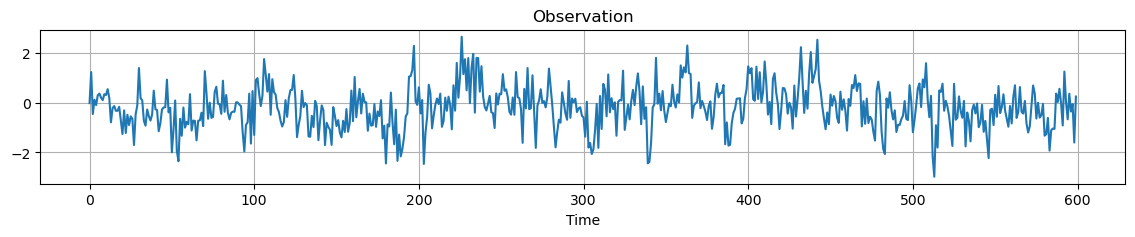

In [5]:
# Which sample to show
ind = 0

plt.figure(figsize=(14,2))

plt.plot(y[0,:])
plt.grid()
plt.xlabel("Time")
plt.title("Observation")

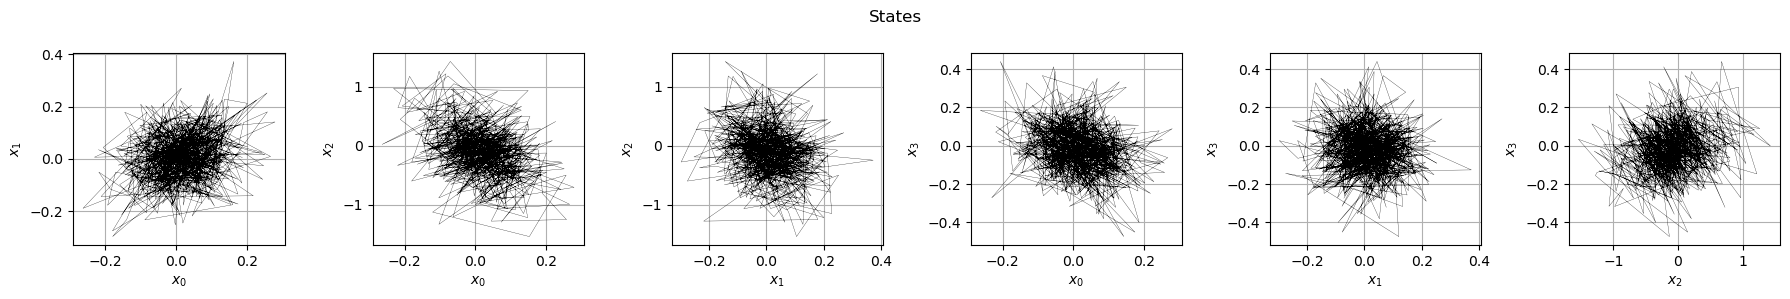

In [6]:
# Which sample to show
ind = 0

pairs = [(0, 1), (0,2), (1,2), (0,3), (1,3), (2,3)]

plt.figure(figsize=(3*len(pairs),3))
plt.suptitle("States")

for k, (j1,j2) in enumerate(pairs):
    plt.subplot(1,len(pairs),k+1)
    plt.plot(x[ind,:,j1], x[ind,:,j2], '-', color='k', lw=0.2, )
    plt.grid()
    plt.xlabel(f"$x_{j1}$")
    plt.ylabel(f"$x_{j2}$")
    
plt.tight_layout()